# QC Testing

In [1]:
import numpy as np
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
import scvi

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
INPUT_FILE = '/home/ubuntu/data/frangieh/rna.h5ad'

In [4]:
adata = ad.read_h5ad(INPUT_FILE)

In [5]:
print('Number of Cells:', adata.n_obs)
print('Number of Genes:', adata.n_vars)

Number of Cells: 218331
Number of Genes: 23712


In [6]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [7]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

In [8]:
adata

AnnData object with n_obs × n_vars = 218331 × 23712
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

## Outlier filtering

In [9]:
def outlier_func(adata_object, metric:str, nmads: int, print_tresholds=False):
    
    metric_median = np.median(adata_object.obs[metric])
    metric_mad = np.median(np.absolute(adata_object.obs[metric] - metric_median))
    upper_T = metric_median + (nmads*metric_mad)
    lower_T = metric_median - (nmads*metric_mad)
    
    if print_tresholds:
        print('upper: ', upper_T)
        print('lower: ', lower_T)

    return (adata_object.obs[metric] > upper_T) |(adata_object.obs[metric] < lower_T)

In [10]:
def qc_plots(adata):
    sc.pl.violin(
    adata,
    ["total_counts", "log1p_total_counts"],
    jitter=0.4,
    multi_panel=True,
    )
    sc.pl.violin(
    adata,
    ["n_genes_by_counts",  "log1p_n_genes_by_counts"],
    jitter=0.4,
    multi_panel=True,
    )
    sc.pl.violin(
    adata,
    ['pct_counts_mt','pct_counts_in_top_50_genes'],
    jitter=0.4,
    multi_panel=True,
    )

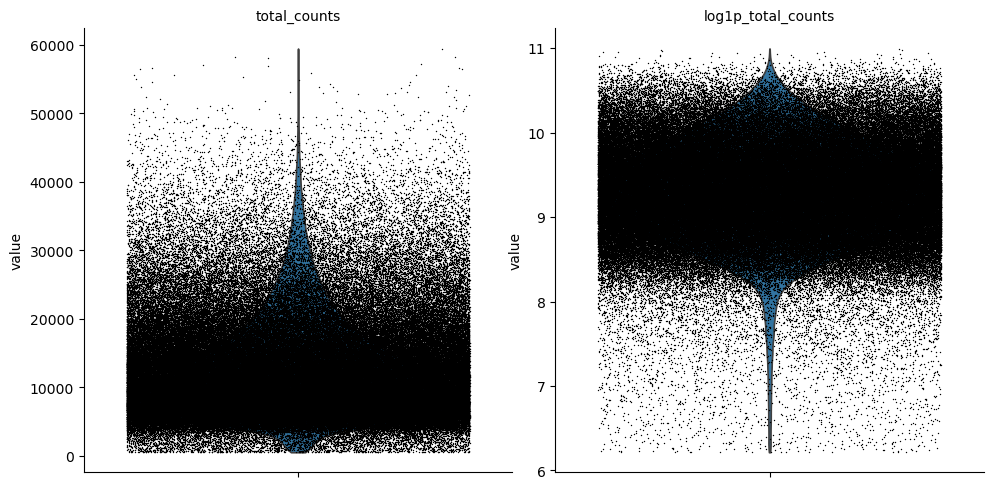

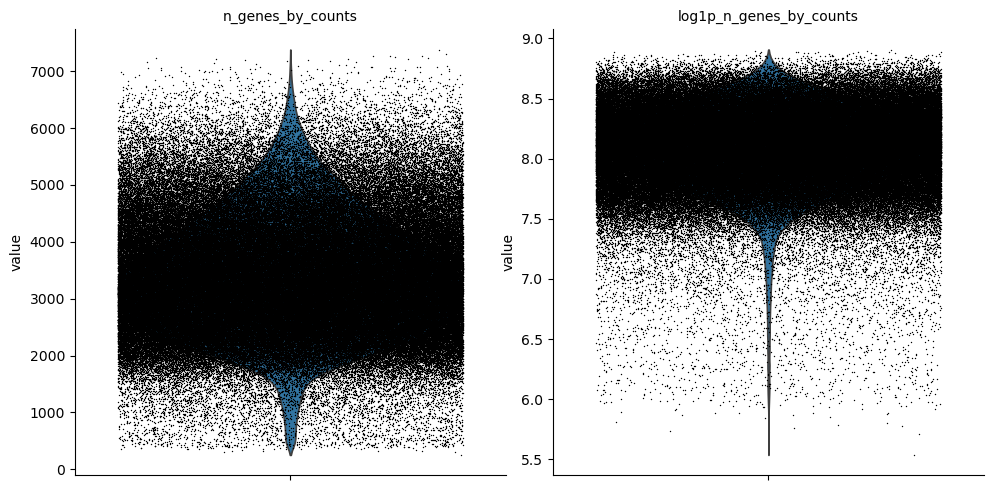

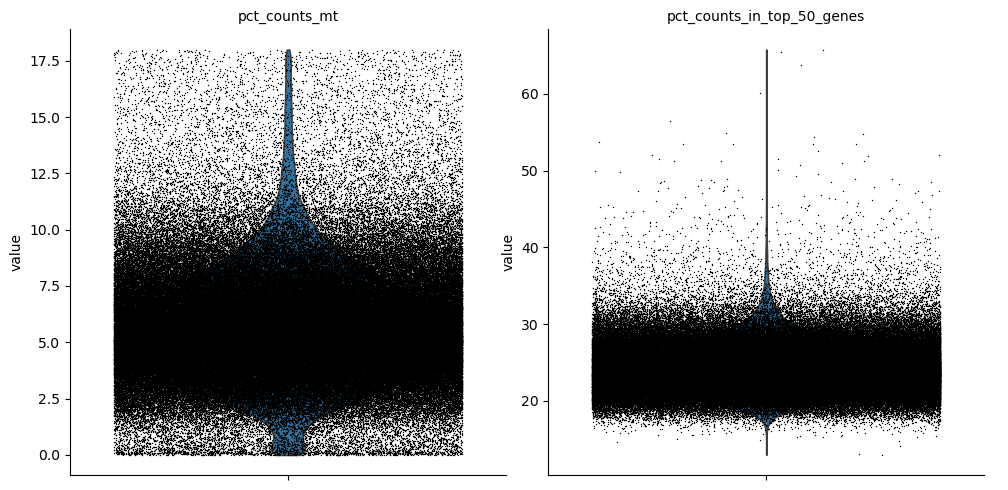

In [11]:
qc_plots(adata)

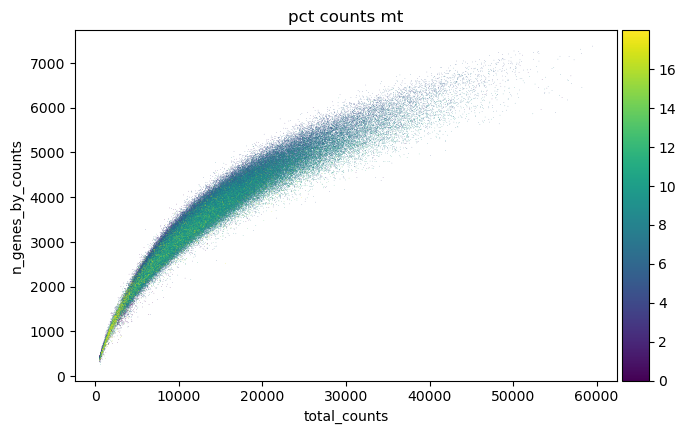

In [12]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

**Notes:** Looking at the AnnData object, we have 218 331 Cells. Due to the high number of available cells, we could afford to be more strict with our filtering.


* `pct_counts_mt`: we can see, that all cells over a thershold of 18 have already been filtered.
* `tota_counts` and `n_genes_by_counts`: There are still some outliers noticable
* `log1p_total_counts`, `log1p_n_genes_by_counts`, `pct_counts_in_top_50_genes`: There are still some outliers noticable



### Min Cells and Genes filters 

In [13]:
test = adata.copy()

In [14]:
sc.pp.filter_cells(test, min_genes=200)
sc.pp.filter_genes(test, min_cells=20)

In [15]:
adata.shape

(218331, 23712)

In [16]:
test.shape

(218331, 22097)

### QC Metrics

In [17]:
outlier_func(adata, 'total_counts', 7).value_counts()

total_counts
False    217071
True       1260
Name: count, dtype: int64

In [18]:
outlier_func(adata, 'n_genes_by_counts', 4).value_counts()

n_genes_by_counts
False    216558
True       1773
Name: count, dtype: int64

In [19]:
outlier_func(adata, 'log1p_total_counts', 4).value_counts()

log1p_total_counts
False    215638
True       2693
Name: count, dtype: int64

In [20]:
outlier_func(adata, 'log1p_n_genes_by_counts', 5).value_counts()

log1p_n_genes_by_counts
False    216090
True       2241
Name: count, dtype: int64

In [21]:
test.obs['outlier'] = (outlier_func(adata, 'total_counts', 6) | 
                       outlier_func(adata, 'log1p_total_counts', 6) |
                       outlier_func(adata, 'n_genes_by_counts', 6) |
                       outlier_func(adata, 'log1p_n_genes_by_counts', 6) |
                       outlier_func(adata, 'pct_counts_mt', 6) |
                       outlier_func(adata, 'pct_counts_in_top_50_genes', 5))

In [22]:
test.obs['outlier'].value_counts()

outlier
False    211345
True       6986
Name: count, dtype: int64

In [23]:
test = test[~test.obs['outlier'], :].copy()
test

AnnData object with n_obs × n_vars = 211345 × 22097
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'outlier'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

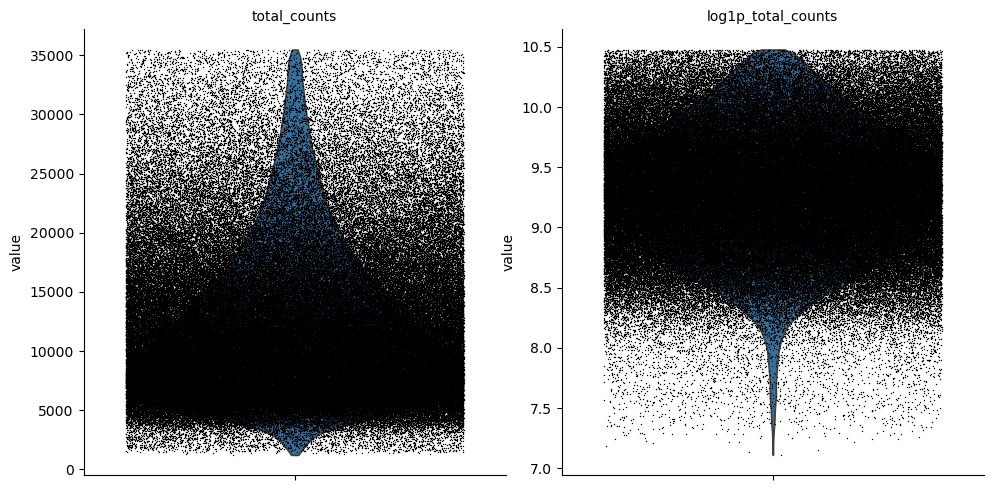

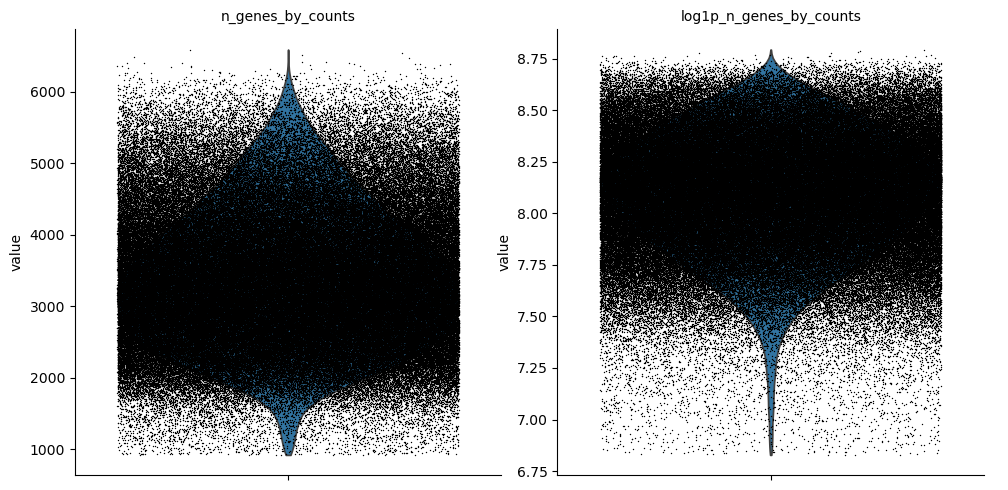

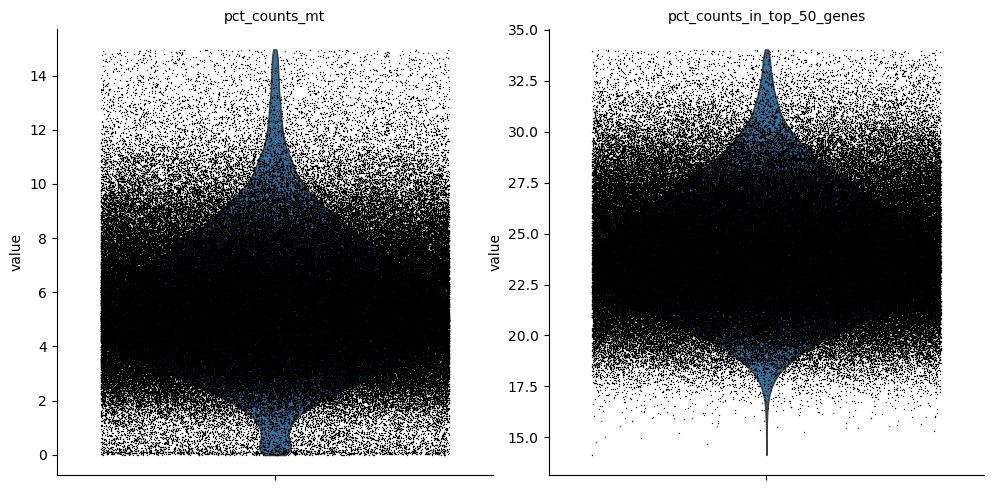

In [24]:
qc_plots(test)

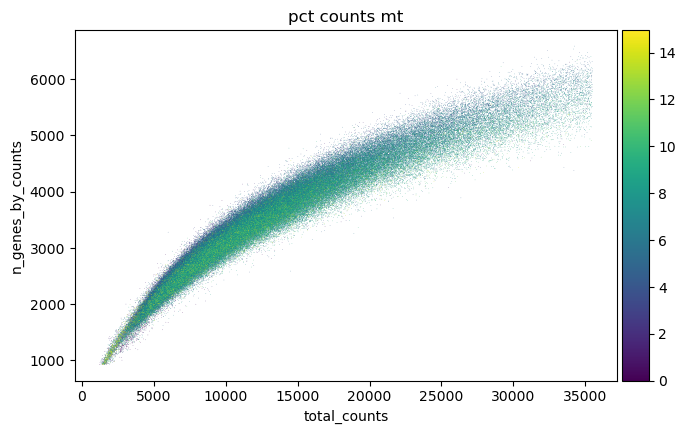

In [25]:
sc.pl.scatter(test, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

## Doublet Detection

In [30]:
adata.obs.columns

Index(['library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA',
       'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer',
       'disease', 'perturbation_type', 'celltype', 'organism',
       'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito',
       'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb'],
      dtype='object')

In [37]:
adata.obs['tissue_type'].value_counts()

tissue_type
cell_line_co-culture    218331
Name: count, dtype: int64

In [33]:
adata.obs['perturbation_2'].value_counts()

perturbation_2
IFNγ          87590
Co-culture    73114
Control       57627
Name: count, dtype: int64

In [ ]:
sc.pp.scrublet(adata, batch_key="perturbation_2")

In [ ]:
)

In [ ]:
scvi.model.SCVI.setup_anndata(test)
vae = scvi.model.SCVI(test)
vae.train()

In [ ]:
solo = scvi.external.SOLO.from_scvi_model(vae)
solo.train()

In [ ]:
df = solo.predict()
df['prediction'] = solo.predict(soft = False)

df.index = df.index.map(lambda x: x[:-2])

df